In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set chart style — makes all charts look professional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the CLEANED dataset (not raw!)
df = pd.read_csv('../data/cleaned/cleaned_job_postings.csv')

print(f"Cleaned data loaded!")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

Cleaned data loaded!
Rows: 12,217 | Columns: 13


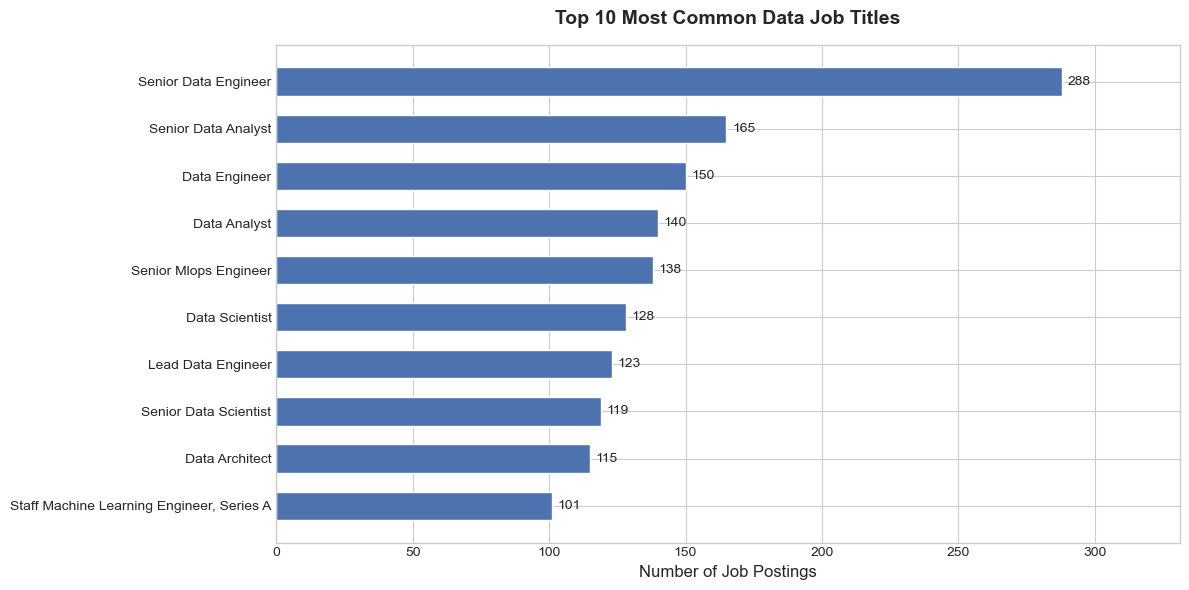

Chart saved!


In [2]:
# ---- CHART 1: Top 10 Most Common Job Titles ----

# Count how many times each job title appears
top_titles = df['job_title'].value_counts().head(10)

# Create the figure (canvas) — width=12, height=6 inches
fig, ax = plt.subplots(figsize=(12, 6))

# Draw a horizontal bar chart
bars = ax.barh(top_titles.index[::-1],  # reverse so #1 is at top
               top_titles.values[::-1],
               color='#4C72B0',
               edgecolor='white',
               height=0.6)

# Add value labels at the end of each bar
for bar, val in zip(bars, top_titles.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

# Labels and title
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_title('Top 10 Most Common Data Job Titles', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top_titles.max() * 1.15)

plt.tight_layout()

# Save the chart
plt.savefig('../outputs/charts/01_top_job_titles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

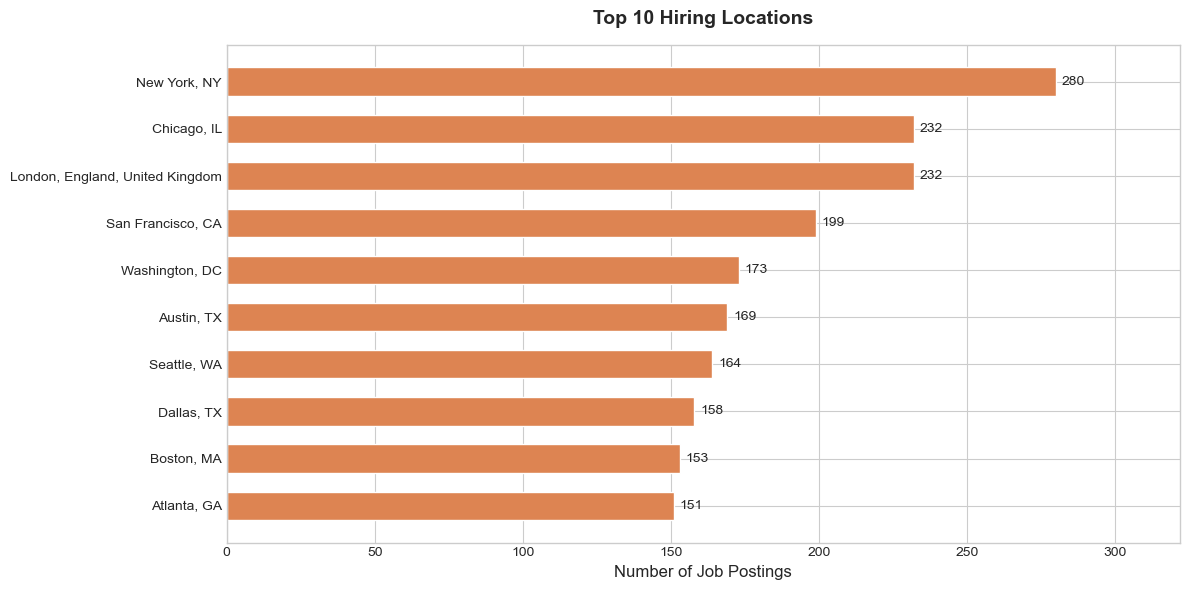

Chart saved!


In [3]:
# ---- CHART 2: Top 10 Hiring Locations ----

top_locations = df['job_location'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top_locations.index[::-1],
               top_locations.values[::-1],
               color='#DD8452',
               edgecolor='white',
               height=0.6)

for bar, val in zip(bars, top_locations.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_title('Top 10 Hiring Locations', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top_locations.max() * 1.15)

plt.tight_layout()
plt.savefig('../outputs/charts/02_top_locations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

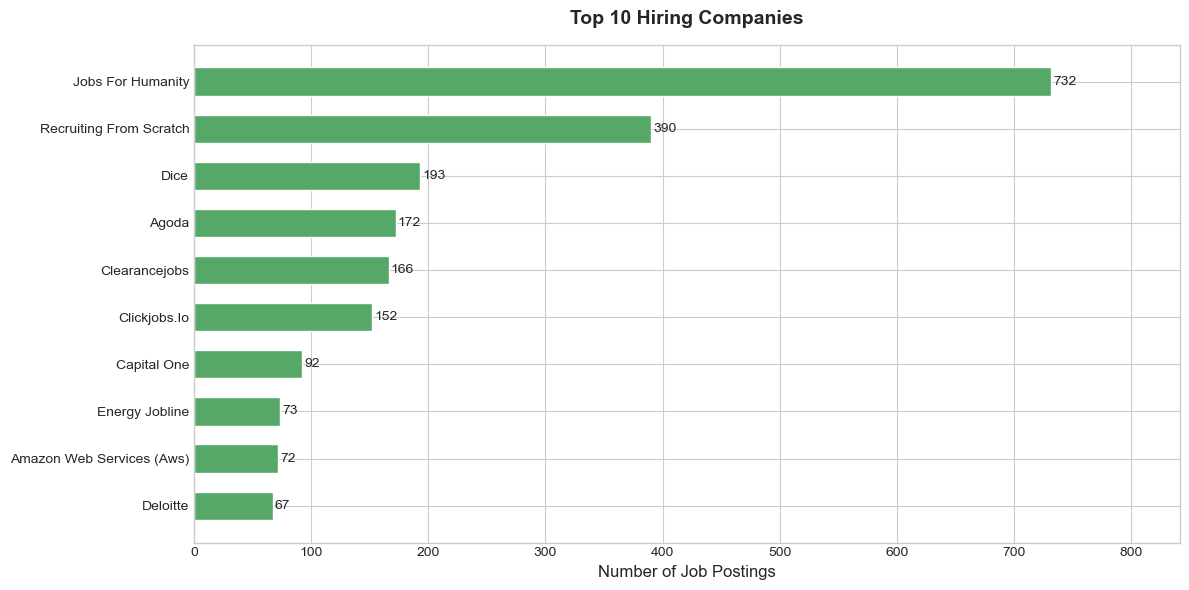

Chart saved!


In [4]:
# ---- CHART 3: Top 10 Hiring Companies ----

top_companies = df['company'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top_companies.index[::-1],
               top_companies.values[::-1],
               color='#55A868',
               edgecolor='white',
               height=0.6)

for bar, val in zip(bars, top_companies.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_title('Top 10 Hiring Companies', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top_companies.max() * 1.15)

plt.tight_layout()
plt.savefig('../outputs/charts/03_top_companies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

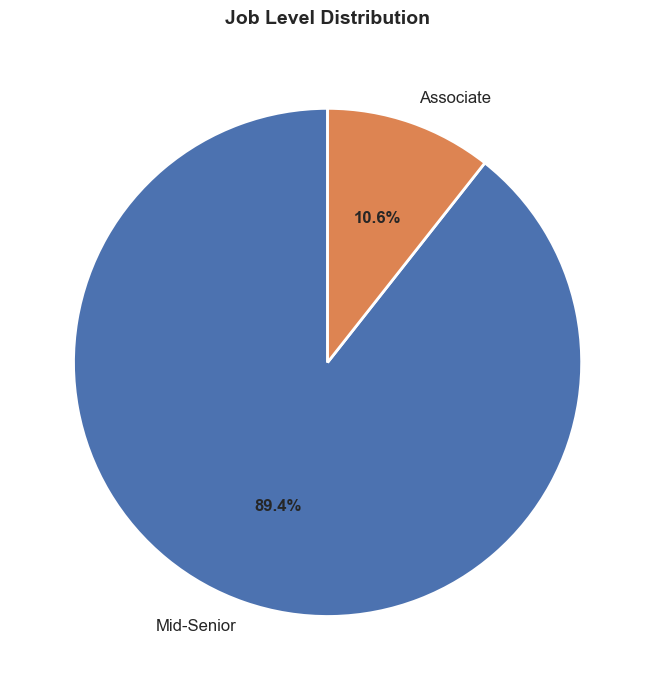

Chart saved!


In [5]:
# ---- CHART 4: Job Level Distribution ----

level_counts = df['job_level'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

colors = ['#4C72B0', '#DD8452']
wedges, texts, autotexts = ax.pie(
    level_counts.values,
    labels=level_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Make text bigger
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Job Level Distribution', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/charts/04_job_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

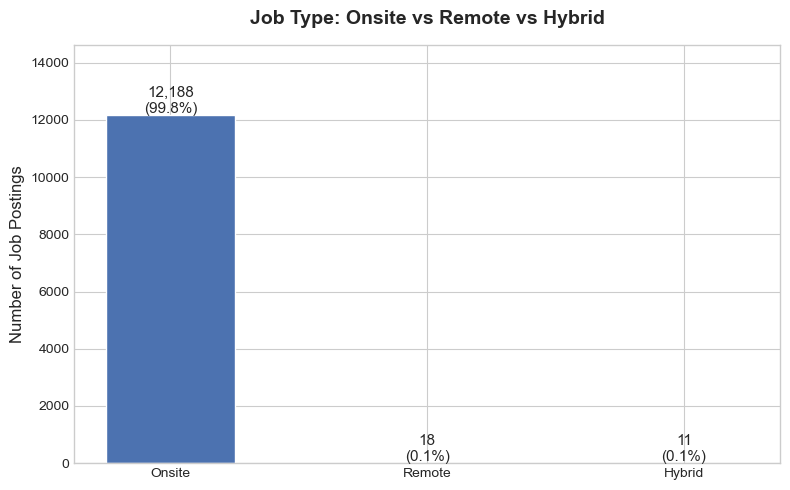

Chart saved!


In [6]:
# ---- CHART 5: Remote vs Onsite vs Hybrid ----

type_counts = df['job_type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#4C72B0', '#55A868', '#DD8452']
bars = ax.bar(type_counts.index,
              type_counts.values,
              color=colors,
              edgecolor='white',
              width=0.5)

for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=11)

ax.set_ylabel('Number of Job Postings', fontsize=12)
ax.set_title('Job Type: Onsite vs Remote vs Hybrid', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, type_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('../outputs/charts/05_job_types.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

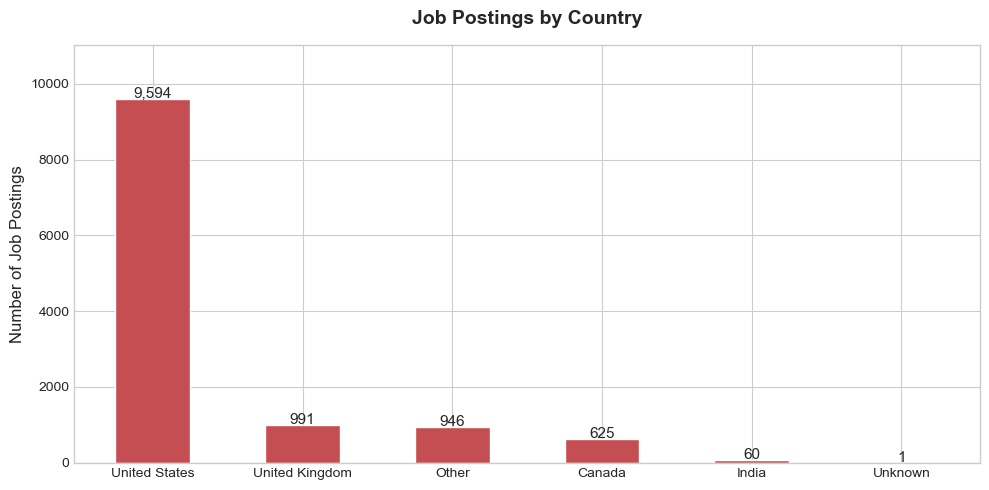

Chart saved!


In [7]:
# ---- CHART 6: Jobs by Country ----

country_counts = df['country'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(country_counts.index,
              country_counts.values,
              color='#C44E52',
              edgecolor='white',
              width=0.5)

for bar, val in zip(bars, country_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', fontsize=11)

ax.set_ylabel('Number of Job Postings', fontsize=12)
ax.set_title('Job Postings by Country', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, country_counts.max() * 1.15)

plt.tight_layout()
plt.savefig('../outputs/charts/06_jobs_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")


In [8]:
import os

# Check if all chart files exist in outputs/charts/
chart_folder = '../outputs/charts/'
files = os.listdir(chart_folder)

print(f"Charts saved so far: {len(files)}")
for f in sorted(files):
    print(f"  {f}")

Charts saved so far: 13
  01_top_job_titles.png
  02_top_locations.png
  03_top_companies.png
  04_job_levels.png
  05_job_types.png
  06_jobs_by_country.png
  07_top_skills.png
  08_jobs_by_date.png
  08_skills_by_level.png
  09_jobs_by_date.png
  09_top_us_cities.png
  10_top_us_cities.png
  dashboard_screenshot.png.png


In [9]:
# See what unique values exist in search_position
print(f"Unique positions: {df['search_position'].nunique()}")
print("\nAll unique values:")
print(df['search_position'].value_counts())

Unique positions: 711

All unique values:
Data Entry Clerk                  1088
Data Base Administrator           1016
Agricultural-Research Engineer     943
Data Communications Analyst        883
Architect                          462
                                  ... 
Supervisor Coffee                    1
Mathematical Technician              1
Loader                               1
Form Builder                         1
Tourist-Information Assistant        1
Name: search_position, Length: 711, dtype: int64


In [10]:
# ---- SKILLS EXTRACTION ----
# We define a list of known data skills and tools
# Then check how many job titles mention each one

skills = [
    # Core technical skills
    'SQL', 'Python', 'Excel', 'Tableau', 'Power BI',
    'R', 'Spark', 'Hadoop', 'Scala', 'Java',
    # Cloud platforms
    'AWS', 'Azure', 'GCP', 'Snowflake', 'Databricks',
    # Data roles / concepts
    'Machine Learning', 'Deep Learning', 'NLP', 'AI',
    'ETL', 'Data Warehouse', 'Analytics', 'Statistics',
    # Databases
    'MongoDB', 'PostgreSQL', 'MySQL', 'Oracle',
    # BI and visualization
    'Looker', 'Qlik', 'SSRS', 'MicroStrategy',
    # Engineering tools
    'Airflow', 'Kafka', 'dbt', 'MLOps', 'DevOps'
]

# Count how many job titles mention each skill
skill_counts = {}
for skill in skills:
    # case=False means we match regardless of uppercase/lowercase
    count = df['job_title'].str.contains(skill, case=False, na=False).sum()
    if count > 0:
        skill_counts[skill] = count

# Convert to a sorted DataFrame
skills_df = pd.DataFrame(
    list(skill_counts.items()),
    columns=['Skill', 'Count']
).sort_values('Count', ascending=False)

print("Skills found in job titles:")
print(skills_df)

Skills found in job titles:
               Skill  Count
5                  R  10879
15  Machine Learning    803
18                AI    533
21         Analytics    446
31             MLOps    166
1             Python    156
0                SQL    134
10               AWS    102
11             Azure     87
13         Snowflake     79
20    Data Warehouse     75
26            Oracle     56
9               Java     53
29           Airflow     46
14        Databricks     44
4           Power BI     31
19               ETL     29
12               GCP     28
8              Scala     25
22        Statistics     25
6              Spark     24
3            Tableau     17
32            DevOps     13
17               NLP     13
7             Hadoop      8
2              Excel      8
23           MongoDB      6
16     Deep Learning      6
30             Kafka      5
28     MicroStrategy      3
24        PostgreSQL      2
25             MySQL      2
27              SSRS      1


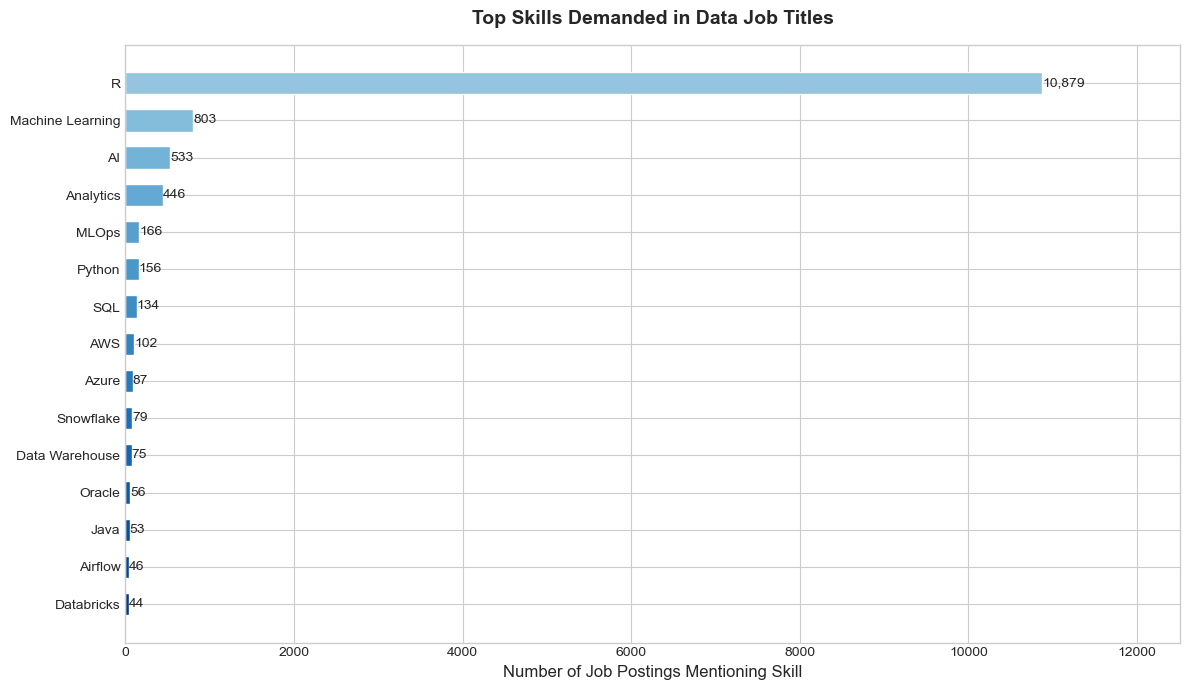

Chart saved!


In [11]:
# ---- CHART 7: Top Skills Demanded ----

# Take top 15 skills
top_skills = skills_df.head(15)

fig, ax = plt.subplots(figsize=(12, 7))

# Color bars by count intensity
colors = plt.cm.Blues(
    [0.4 + 0.6 * (i / len(top_skills)) 
     for i in range(len(top_skills))]
)[::-1]

bars = ax.barh(
    top_skills['Skill'][::-1],
    top_skills['Count'][::-1],
    color=colors,
    edgecolor='white',
    height=0.6
)

# Add value labels
for bar, val in zip(bars, top_skills['Count'][::-1]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center', fontsize=10
    )

ax.set_xlabel('Number of Job Postings Mentioning Skill', fontsize=12)
ax.set_title('Top Skills Demanded in Data Job Titles', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top_skills['Count'].max() * 1.15)

plt.tight_layout()
plt.savefig('../outputs/charts/07_top_skills.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

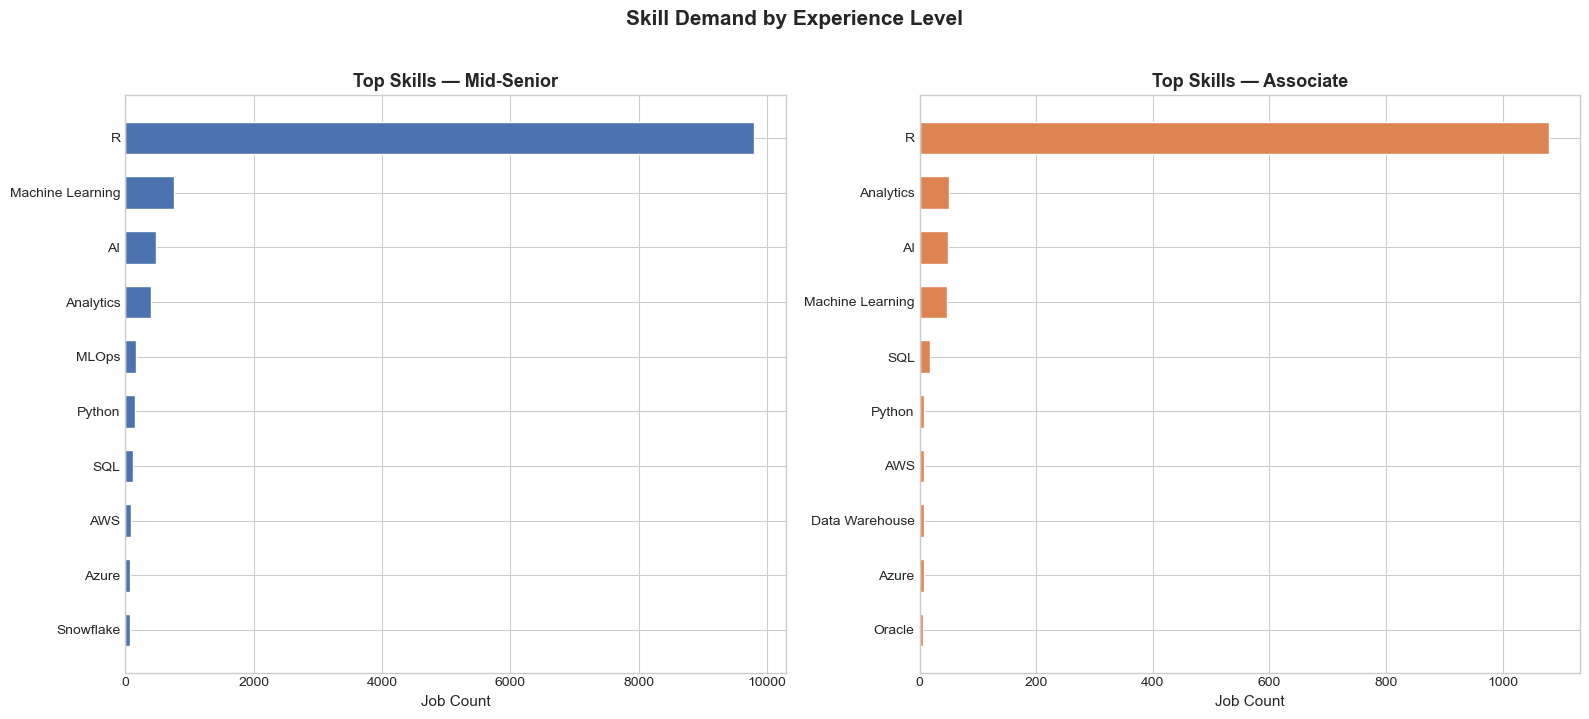

Chart saved!


In [12]:
# ---- CHART 8: Skills by Job Level ----

# Compare skill mentions between Mid-Senior and Associate roles
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, level in enumerate(['Mid-Senior', 'Associate']):
    # Filter data for this job level
    level_df = df[df['job_level'] == level]
    
    # Count skills for this level
    level_skill_counts = {}
    for skill in skills:
        count = level_df['job_title'].str.contains(
            skill, case=False, na=False
        ).sum()
        if count > 0:
            level_skill_counts[skill] = count
    
    # Sort and take top 10
    level_skills = pd.DataFrame(
        list(level_skill_counts.items()),
        columns=['Skill', 'Count']
    ).sort_values('Count', ascending=False).head(10)
    
    color = '#4C72B0' if level == 'Mid-Senior' else '#DD8452'
    
    axes[idx].barh(
        level_skills['Skill'][::-1],
        level_skills['Count'][::-1],
        color=color,
        edgecolor='white',
        height=0.6
    )
    axes[idx].set_title(
        f'Top Skills — {level}',
        fontsize=13, fontweight='bold'
    )
    axes[idx].set_xlabel('Job Count', fontsize=11)

plt.suptitle(
    'Skill Demand by Experience Level',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/charts/08_skills_by_level.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved!")

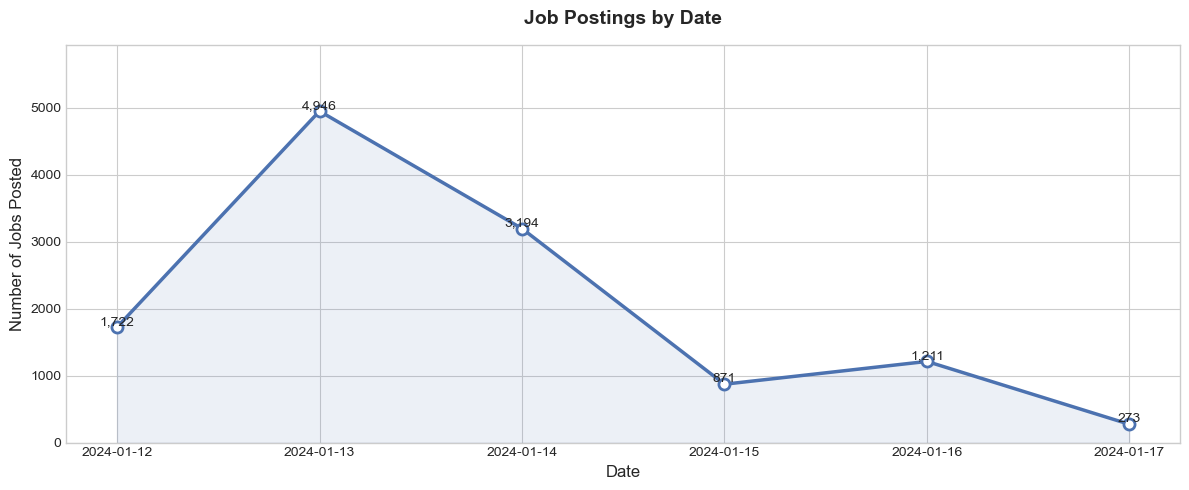

Chart saved!


In [13]:
# ---- CHART 9: Jobs Posted by Date ----

# Convert first_seen back to datetime if needed
df['first_seen'] = pd.to_datetime(df['first_seen'])

# Count jobs per date
daily_jobs = df.groupby('first_seen').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_jobs['first_seen'],
    daily_jobs['count'],
    color='#4C72B0',
    linewidth=2.5,
    marker='o',
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2
)

# Fill area under line
ax.fill_between(
    daily_jobs['first_seen'],
    daily_jobs['count'],
    alpha=0.1,
    color='#4C72B0'
)

# Add value labels on each point
for _, row in daily_jobs.iterrows():
    ax.text(
        row['first_seen'],
        row['count'] + 30,
        f"{int(row['count']):,}",
        ha='center', fontsize=10
    )

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Jobs Posted', fontsize=12)
ax.set_title('Job Postings by Date', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, daily_jobs['count'].max() * 1.2)

plt.tight_layout()
plt.savefig('../outputs/charts/09_jobs_by_date.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

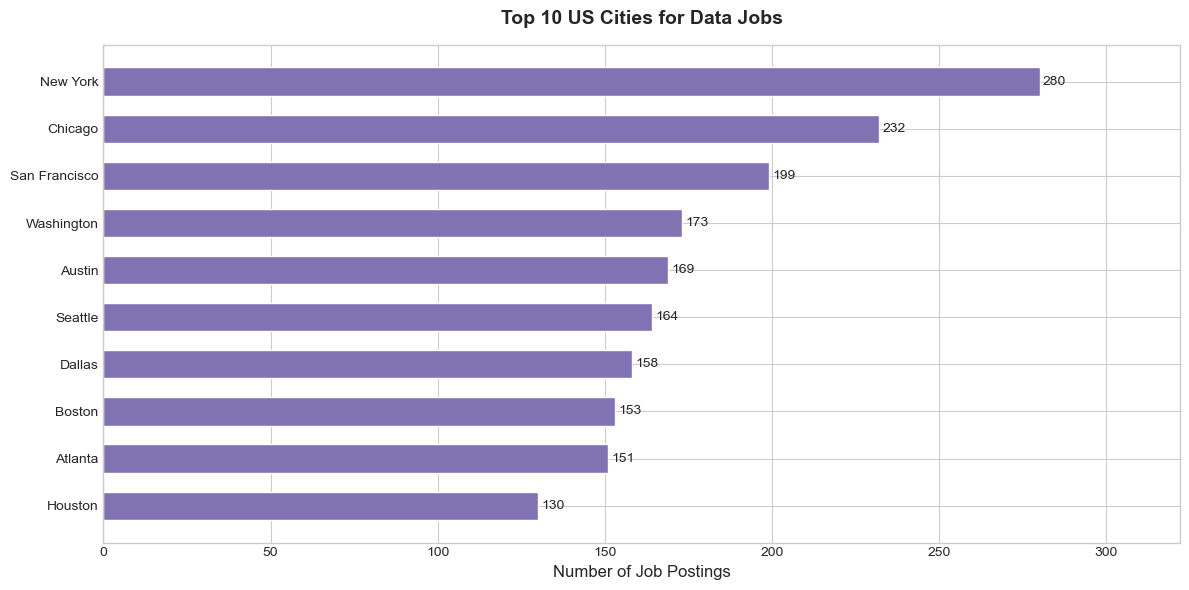

Chart saved!


In [14]:
# ---- CHART 10: Top US Cities ----

# Filter only US jobs
us_df = df[df['country'] == 'United States']

# Extract just the city name (before the comma)
us_df = us_df.copy()
us_df['city'] = us_df['job_location'].str.split(',').str[0].str.strip()

# Top 10 US cities
top_cities = us_df['city'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    top_cities.index[::-1],
    top_cities.values[::-1],
    color='#8172B3',
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars, top_cities.values[::-1]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center', fontsize=10
    )

ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_title('Top 10 US Cities for Data Jobs', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top_cities.max() * 1.15)

plt.tight_layout()
plt.savefig('../outputs/charts/10_top_us_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [15]:
df['job_skills'].head(10)

KeyError: 'job_skills'

In [ ]:
import pandas as pd
df = pd.read_csv('../data/cleaned_job_data.csv')
df.shape

In [ ]:
import os
os.listdir('../data')

In [ ]:
os.listdir('../data/cleaned')

In [ ]:
df = pd.read_csv('../data/cleaned/cleaned_job_postings.csv')
df.shape

In [ ]:
df['job_skills'].head(10)

In [ ]:
df.columns.tolist()

In [ ]:
raw = pd.read_csv('../data/raw/' + os.listdir('../data/raw')[0])
raw.columns.tolist()

In [ ]:
# ---- SKILLS EXTRACTION ----
skills = [
    'SQL', 'Python', 'Excel', 'Tableau', 'Power BI',
    'R', 'Spark', 'Hadoop', 'Scala', 'Java',
    'AWS', 'Azure', 'GCP', 'Snowflake', 'Databricks',
    'Machine Learning', 'Deep Learning', 'NLP', 'AI',
    'ETL', 'Data Warehouse', 'Analytics', 'Statistics',
    'MongoDB', 'PostgreSQL', 'MySQL', 'Oracle',
    'Looker', 'Qlik', 'SSRS', 'MicroStrategy',
    'Airflow', 'Kafka', 'dbt', 'MLOps', 'DevOps'
]

# Count how many job titles mention each skill
skill_counts = {}
for skill in skills:
    count = df['job_title'].str.contains(skill, case=False, na=False).sum()
    if count > 0:
        skill_counts[skill] = count

# Convert to sorted DataFrame
skills_df = pd.DataFrame(
    list(skill_counts.items()),
    columns=['Skill', 'Count']
).sort_values('Count', ascending=False)

print("Skills found in job titles:")
print(skills_df.to_string())

In [ ]:
import re

# ---- FIXED SKILLS EXTRACTION ----
skills = [
    'SQL', 'Python', 'Excel', 'Tableau', 'Power BI',
    'Spark', 'Hadoop', 'Scala', 'Java',
    'AWS', 'Azure', 'GCP', 'Snowflake', 'Databricks',
    'Machine Learning', 'Deep Learning', 'NLP',
    'ETL', 'Data Warehouse', 'Analytics', 'Statistics',
    'MongoDB', 'PostgreSQL', 'MySQL', 'Oracle',
    'Looker', 'Qlik', 'SSRS', 'MicroStrategy',
    'Airflow', 'Kafka', 'dbt', 'MLOps', 'DevOps',
    'AI', 'R'
]

skill_counts = {}
for skill in skills:
    pattern = r'\b' + re.escape(skill) + r'\b'
    count = df['job_title'].str.contains(pattern, case=False, na=False).sum()
    if count > 0:
        skill_counts[skill] = count

skills_df = pd.DataFrame(
    list(skill_counts.items()),
    columns=['Skill', 'Count']
).sort_values('Count', ascending=False).reset_index(drop=True)

print("Fixed skills count:")
print(skills_df.to_string())

In [ ]:
# ---- CHART 7: Top 15 Skills Demanded ----

top_skills = skills_df.head(15)

fig, ax = plt.subplots(figsize=(12, 7))

# Color bars by intensity — darker = more in demand
colors = plt.cm.Blues(
    [0.4 + 0.6 * (i / len(top_skills))
     for i in range(len(top_skills))]
)[::-1]

bars = ax.barh(
    top_skills['Skill'][::-1],
    top_skills['Count'][::-1],
    color=colors,
    edgecolor='white',
    height=0.6
)

# Add value labels
for bar, val in zip(bars, top_skills['Count'][::-1]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center', fontsize=10
    )

ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_title('Top 15 In-Demand Skills in Data Jobs',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top_skills['Count'].max() * 1.15)

plt.tight_layout()
plt.savefig('../outputs/charts/07_top_skills.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [ ]:
# ---- CHART 8: Jobs Posted by Date ----

df['first_seen'] = pd.to_datetime(df['first_seen'])
daily_jobs = df.groupby('first_seen').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_jobs['first_seen'],
    daily_jobs['count'],
    color='#4C72B0',
    linewidth=2.5,
    marker='o',
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2
)

ax.fill_between(
    daily_jobs['first_seen'],
    daily_jobs['count'],
    alpha=0.1,
    color='#4C72B0'
)

for _, row in daily_jobs.iterrows():
    ax.text(
        row['first_seen'],
        row['count'] + 30,
        f"{int(row['count']):,}",
        ha='center', fontsize=10
    )

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Jobs Posted', fontsize=12)
ax.set_title('Job Postings by Date', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, daily_jobs['count'].max() * 1.2)

plt.tight_layout()
plt.savefig('../outputs/charts/08_jobs_by_date.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [ ]:
# ---- CHART 9: Top US Cities ----

us_df = df[df['country'] == 'United States'].copy()
us_df['city'] = us_df['job_location'].str.split(',').str[0].str.strip()
top_cities = us_df['city'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    top_cities.index[::-1],
    top_cities.values[::-1],
    color='#8172B3',
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars, top_cities.values[::-1]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center', fontsize=10
    )

ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_title('Top 10 US Cities for Data Jobs',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top_cities.max() * 1.15)

plt.tight_layout()
plt.savefig('../outputs/charts/09_top_us_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [ ]:
import os

files = sorted(os.listdir('../outputs/charts/'))
print(f"Total charts saved: {len(files)}")
for f in files:
    print(f"  {f}")